# Chronic Kidney Disease Presence Prediction — Model Training Run

> **For research and educational purposes only.** The model below is trained on a
> historical public dataset. Its output is not a medical diagnosis and not medical
> advice. See the model card for what this model must **not** be used for.

This notebook **does not train anything** — it reads the artifacts produced by

```
python -m scripts.train_kidney
```

so every number shown here is the same number in `reports/kidney/` and
`models/kidney/metadata.json`. Re-run that script to refresh them.


In [1]:
import sys, os
# Make the repository root importable when the kernel starts in notebooks/.
_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if _root not in sys.path:
    sys.path.insert(0, _root)
os.chdir(_root)

import json
from pathlib import Path

import joblib
import pandas as pd
from IPython.display import Image, Markdown, display

pd.set_option("display.max_columns", 60)

DISEASE = "kidney"
reports = Path("reports") / DISEASE
models = Path("models") / DISEASE

metrics = json.loads((reports / "metrics.json").read_text(encoding="utf-8"))
card = json.loads((models / "metadata.json").read_text(encoding="utf-8"))
shap_global = json.loads((reports / "shap_global.json").read_text(encoding="utf-8"))

print(card["module"])
print("algorithm :", card["model"]["algorithm"])
print("calibration:", card["model"]["calibration"])


Chronic Kidney Disease Presence Prediction
algorithm : svc
calibration: raw


## 1. How the data was split

Preprocessing (imputation, scaling, one-hot) happens **inside** the model pipeline, so
it is fitted on training folds only and never sees the held-out rows.


In [2]:
pd.Series(metrics["split"]).to_frame("value")

,value
n_total,400.000
n_train,320.000
n_test,80.000
n_duplicate_rows,0.000
overall_positive_rate,0.625
train_positive_rate,0.625
test_positive_rate,0.625


## 2. Model comparison

Five candidate pipelines, 5-fold cross-validated on the training set.

In [3]:
pd.read_csv(reports / "model_comparison.csv")

,model,smote,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std,rank_score
0,random_forest,False,0.9996,0.0005,0.9998,0.0003,1.00,0.0000,0.9902,0.0119,0.9951,0.0060,0.9997
1,lightgbm,False,0.9990,0.0016,0.9994,0.0009,0.99,0.0122,0.9951,0.0098,0.9925,0.0062,0.9974
2,svc,False,1.0000,0.0000,1.0000,0.0000,0.98,0.0292,1.0000,0.0000,0.9897,0.0151,0.9960
3,xgboost,False,0.9971,0.0038,0.9983,0.0022,0.98,0.0292,0.9801,0.0291,0.9800,0.0281,0.9941
4,logreg,False,0.9990,0.0021,0.9994,0.0012,0.97,0.0292,1.0000,0.0000,0.9845,0.0151,0.9933


### Was the winner meaningfully better?

`selection_margin` compares the tuned top-2 against the fold-to-fold standard deviation.
When the gap is smaller than that noise, the leaderboard is **not** a quality ranking.


In [4]:
pd.Series(metrics["selection_margin"]).to_frame("value")

,value
selected,svc
selected_tuned_roc_auc,1.0
runner_up,random_forest
runner_up_tuned_roc_auc,0.999792
gap,0.000208
cv_roc_auc_std,0.0
decisive,False
reasons_to_doubt,"[the gap (0.0002) is below 0.005, the practica..."
gap_within_cv_noise,True


In [5]:
display(Markdown((reports / "SELECTION.md").read_text(encoding="utf-8")))

# Model selection — kidney

Selection criteria (in order): ROC-AUC and PR-AUC (discrimination), then recall/sensitivity for the positive class, then calibration. **Not** accuracy.

## Cross-validated comparison (training set, 5-fold stratified CV)

| model | smote | roc_auc_mean | roc_auc_std | pr_auc_mean | pr_auc_std | recall_mean | recall_std | precision_mean | precision_std | f1_mean | f1_std | rank_score |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| random_forest | False | 0.9996 | 0.0005 | 0.9998 | 0.0003 | 1.0000 | 0.0000 | 0.9902 | 0.0119 | 0.9951 | 0.0060 | 0.9997 |
| lightgbm | False | 0.9990 | 0.0016 | 0.9994 | 0.0009 | 0.9900 | 0.0122 | 0.9951 | 0.0098 | 0.9925 | 0.0062 | 0.9974 |
| svc | False | 1.0000 | 0.0000 | 1.0000 | 0.0000 | 0.9800 | 0.0292 | 1.0000 | 0.0000 | 0.9897 | 0.0151 | 0.9960 |
| xgboost | False | 0.9971 | 0.0038 | 0.9983 | 0.0022 | 0.9800 | 0.0292 | 0.9801 | 0.0291 | 0.9800 | 0.0281 | 0.9941 |
| logreg | False | 0.9990 | 0.0021 | 0.9994 | 0.0012 | 0.9700 | 0.0292 | 1.0000 | 0.0000 | 0.9845 | 0.0151 | 0.9933 |

## Tuning (RandomizedSearchCV, scoring = ROC-AUC)

- **svc**: CV ROC-AUC 1.0000
  - params: `{'clf__C': 8.471801418819979, 'clf__gamma': 0.024810409748678097, 'clf__kernel': 'rbf'}`
- **random_forest**: CV ROC-AUC 0.9998
  - params: `{'clf__max_depth': 6, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 761}`
- **lightgbm**: CV ROC-AUC 0.9996
  - params: `{'clf__colsample_bytree': 0.749816047538945, 'clf__learning_rate': 0.2536999076681772, 'clf__max_depth': 6, 'clf__min_child_samples': 12, 'clf__n_estimators': 220, 'clf__num_leaves': 117, 'clf__reg_lambda': 0.21751953118777648, 'clf__subsample': 0.6399899663272012}`

## Selected: `svc`

`svc` was chosen from 5 candidate pipelines. The cross-validated ranking (0.4·ROC-AUC + 0.4·PR-AUC + 0.2·recall) put `random_forest` first before tuning, with `svc` at rank 3. After randomised hyper-parameter search the tuned cross-validated ROC-AUC scores were: svc 1.0000, random_forest 0.9998, lightgbm 0.9996; `svc` was highest and was refit on the full training set. Accuracy was recorded but was not used as a selection criterion.

### How decisive was this?

**Not decisive.** `svc` beat `random_forest` by 0.0002 cross-validated ROC-AUC, but:

- the gap (0.0002) is below 0.005, the practical resolution of ROC-AUC at this sample size.
- both models exceed 0.99 ROC-AUC, where the metric is saturated and cannot separate them (a standard deviation of 0.0 here means no resolution left, not a precise estimate).

Read the leaderboard as *these models perform comparably*, not as a quality ranking. A different random seed could reorder them. The choice of algorithm here should not be presented as a finding.

---
*Generated by `ml.training.experiment.run_experiment`. Every number above comes from that run.*


## 3. Calibration

The wrapper is chosen on **out-of-fold training** scores. The test-set table below is
reported for transparency only — choosing on it would make the test metrics optimistic.


In [6]:
print("selection (training out-of-fold):")
display(pd.DataFrame(metrics["calibration_selection_train_cv"]).set_index("method"))
print("\nreported only (test set) — NOT used to choose:")
display(pd.DataFrame(metrics["calibration_test_comparison"]).set_index("method"))
print("\nchosen:", card["model"]["calibration"])
print(card["model"]["calibration_rationale"])


selection (training out-of-fold):


,brier,roc_auc
method,,
raw,0.007669,0.999875
sigmoid,0.014006,0.999542
isotonic,0.007722,0.999625



reported only (test set) — NOT used to choose:


,brier,roc_auc
method,,
raw,0.012681,0.998667
sigmoid,0.013442,1.000000
isotonic,0.007160,1.000000



chosen: raw
Selected 'raw' by out-of-fold Brier score on the training set: 0.0077 vs raw 0.0077; cross-validated ROC-AUC 0.9999 vs raw 0.9999 (tolerance 0.01). The test set played no part in this choice.


## 4. Held-out test performance

In [7]:
rows = {
    "threshold 0.5": metrics["test_set_threshold_0.5"],
    "sensitivity-oriented": {k: v for k, v in metrics["test_set_alternative_threshold"].items()
                             if k != "threshold_rule"},
}
display(pd.DataFrame(rows).loc[
    ["n", "threshold", "roc_auc", "pr_auc", "recall_sensitivity", "specificity",
     "precision", "f1", "accuracy", "brier", "cm_tn", "cm_fp", "cm_fn", "cm_tp"]
])
print(metrics["test_set_alternative_threshold"]["threshold_rule"])


,threshold 0.5,sensitivity-oriented
n,80.000000,80.000000
threshold,0.500000,0.579237
roc_auc,0.998667,0.998667
pr_auc,0.999208,0.999208
recall_sensitivity,0.960000,0.960000
specificity,0.966667,1.000000
precision,0.979592,1.000000
f1,0.969697,0.979592
accuracy,0.962500,0.975000
brier,0.012681,0.012681


Youden's J (max sensitivity + specificity - 1) maximised on out-of-fold predictions over the TRAINING set, then applied unchanged to the test set. The test set played no part in choosing it.


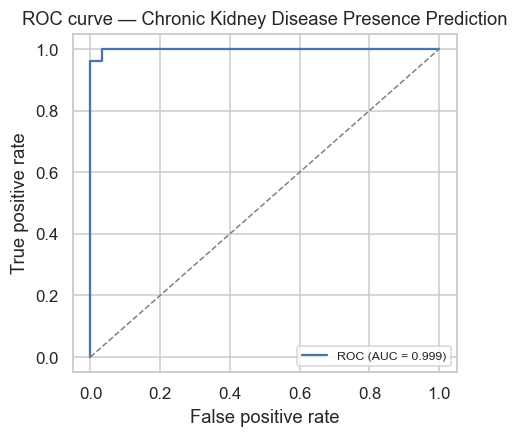

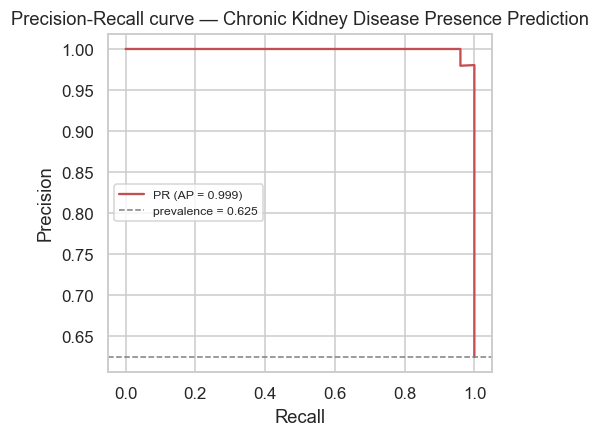

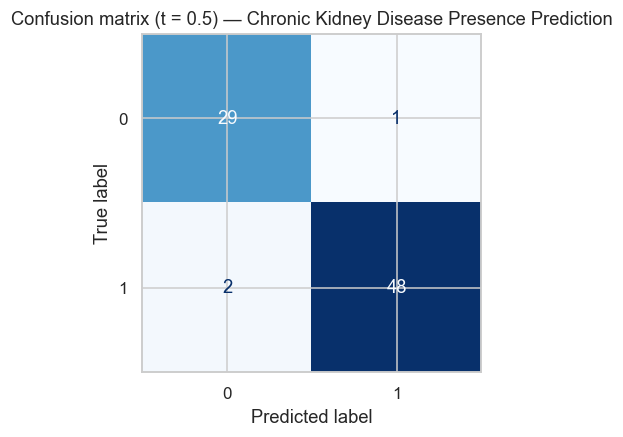

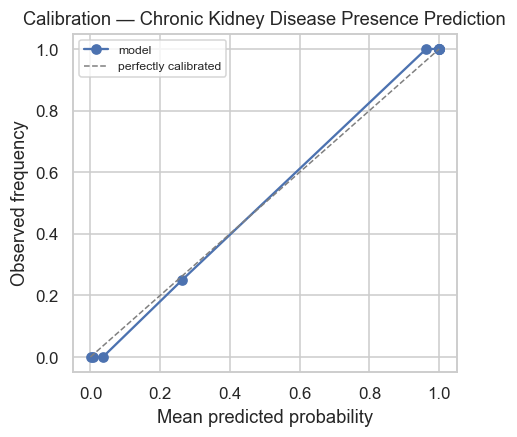

In [8]:
for name in ["roc_curve", "pr_curve", "confusion_matrix", "calibration_curve"]:
    png = reports / "figures" / f"{name}.png"
    if png.exists():
        display(Image(filename=str(png)))


### Threshold sweep

How precision, recall and specificity trade off across the decision threshold.

In [9]:
pd.read_csv(reports / "threshold_sweep.csv")

,threshold,precision,recall_sensitivity,specificity,f1,accuracy
0,0.05,0.8772,1.00,0.7667,0.9346,0.9125
1,0.10,0.9434,1.00,0.9000,0.9709,0.9625
2,0.15,0.9434,1.00,0.9000,0.9709,0.9625
3,0.20,0.9615,1.00,0.9333,0.9804,0.9750
4,0.25,0.9804,1.00,0.9667,0.9901,0.9875
5,0.30,0.9804,1.00,0.9667,0.9901,0.9875
6,0.35,0.9804,1.00,0.9667,0.9901,0.9875
7,0.40,0.9804,1.00,0.9667,0.9901,0.9875
8,0.45,0.9804,1.00,0.9667,0.9901,0.9875
9,0.50,0.9796,0.96,0.9667,0.9697,0.9625


## 4b. What actually drives this score?

A high ROC-AUC is not by itself evidence that the model learned clinical structure — it
can also come from how the data was collected. The probe below discards **every measured
value** and trains only on *which values are missing*. If that alone reproduces most of
the headline score, the model is largely reading which tests a clinician chose to order.

That is not train/test leakage — the split stays clean — but it is a ceiling on how far
the result transfers to a setting where these tests are ordered routinely.


In [10]:
diag = metrics.get("diagnostics", {})
print(diag.get("attribution_note", "(no diagnostics recorded)"))
print()

probe = diag.get("missingness_only_probe")
if probe:
    print("missingness-indicators-only model:")
    for k in ("n_indicator_features", "cv_roc_auc_mean", "cv_roc_auc_std",
              "test_roc_auc", "test_pr_auc", "test_accuracy"):
        if k in probe:
            print(f"  {k:<22} {probe[k]}")
    print(f"\n  full model test ROC-AUC {metrics['test_set_threshold_0.5']['roc_auc']:.4f}")
else:
    print("No missing values in this dataset — measurement pattern cannot carry signal.")

print("\ncomplete-case analysis (why it was not used instead):")
print(" ", diag.get("complete_case"))


Missingness indicators alone reach test ROC-AUC 0.8023 against the full model's 0.9987 (gap +0.1963). A meaningful part of the signal comes from which values were recorded rather than their values.

missingness-indicators-only model:
  n_indicator_features   24
  cv_roc_auc_mean        0.86
  cv_roc_auc_std         0.044452934301973335
  test_roc_auc           0.8023333333333332
  test_pr_auc            0.8789651384651385
  test_accuracy          0.775

  full model test ROC-AUC 0.9987

complete-case analysis (why it was not used instead):
  {'n_total': 400, 'n_complete_cases': 158, 'pct_retained': 39.5, 'positive_rate_all': 0.625, 'positive_rate_complete_cases': 0.2722}


In [11]:
miss_csv = reports / "missingness_vs_target.csv"
if miss_csv.exists():
    display(Markdown("**Is a column's missingness itself predictive of the target?**"))
    display(pd.read_csv(miss_csv))
else:
    print("No missing values to analyse.")


**Is a column's missingness itself predictive of the target?**

,column,n_missing,pct_missing,positive_rate_when_missing,positive_rate_when_present,difference,overall_positive_rate
0,pcc,4,1.00,0.0000,0.6313,-0.6313,0.625
1,ba,4,1.00,0.0000,0.6313,-0.6313,0.625
2,htn,2,0.50,0.0000,0.6281,-0.6281,0.625
3,dm,2,0.50,0.0000,0.6281,-0.6281,0.625
4,cad,2,0.50,0.0000,0.6281,-0.6281,0.625
5,pe,1,0.25,0.0000,0.6266,-0.6266,0.625
6,ane,1,0.25,0.0000,0.6266,-0.6266,0.625
7,appet,1,0.25,0.0000,0.6266,-0.6266,0.625
8,rbc,152,38.00,0.9408,0.4315,0.5093,0.625
9,rbcc,131,32.75,0.9466,0.4684,0.4782,0.625


## 5. Explainability (SHAP)

SHAP values are computed on the transformed matrix and summed back onto the **original**
feature names. `additivity_max_error` is the largest gap between `base value + sum(SHAP)`
and the model's actual output — near zero means the explanation really does reconstruct
this model rather than being a plausible-looking set of numbers.


In [12]:
print("explainer:", shap_global["explainer"])
print("additivity max error:", shap_global["additivity_max_error"])
display(pd.DataFrame(shap_global["global_importance"]))


explainer: kernel
additivity max error: 1.1102230246251565e-16


,rank,feature,mean_abs_shap,mean_shap,description
0,1,sg,0.076203,-0.007279,Urine specific gravity (1.005-1.025)
1,2,pcv,0.069881,-0.019031,Packed cell volume (%)
2,3,hemo,0.065408,-0.010731,Haemoglobin (g/dl)
3,4,al,0.048012,0.003993,Albumin (0-5 ordinal scale)
4,5,htn,0.032776,-0.001380,Hypertension (yes / no)
5,6,rbcc,0.032334,-0.002113,Red blood cell count (millions/cu mm)
6,7,bgr,0.028260,0.000506,Random blood glucose (mg/dl)
7,8,dm,0.027674,0.000081,Diabetes mellitus (yes / no)
8,9,sc,0.017793,-0.005276,Serum creatinine (mg/dl)
9,10,bu,0.016104,-0.000388,Blood urea (mg/dl)


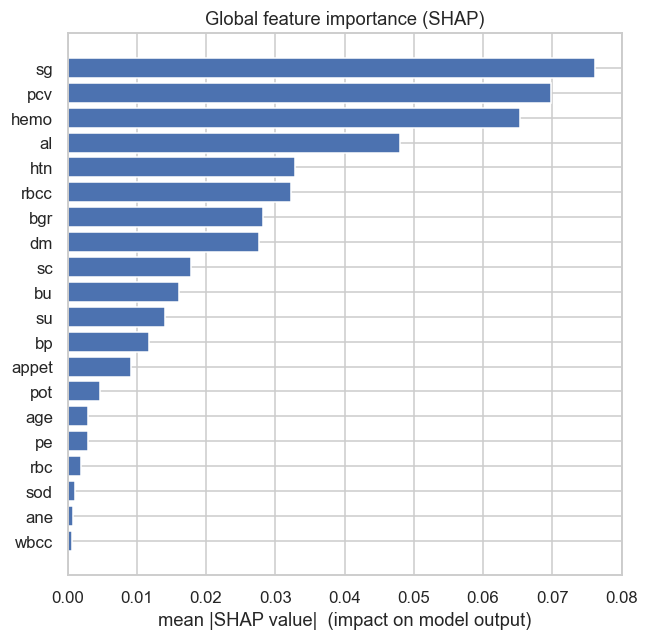

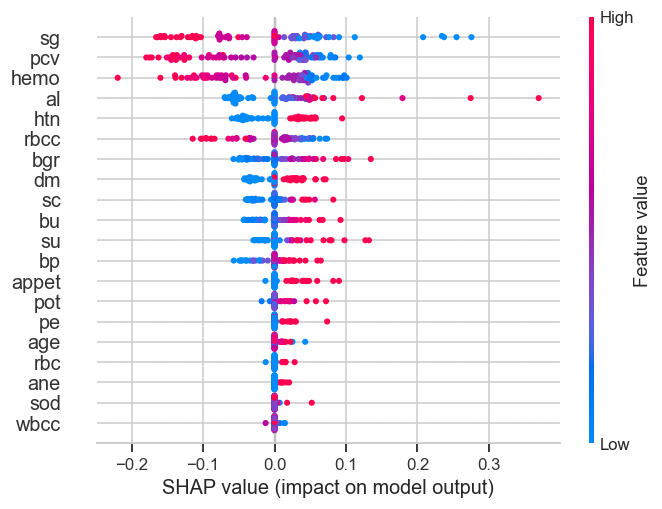

In [13]:
for name in ["shap_global_importance", "shap_beeswarm"]:
    png = reports / "figures" / f"{name}.png"
    if png.exists():
        display(Image(filename=str(png)))


### A single explained case

Signed contributions for one held-out patient. Positive pushes the model toward the
positive class, negative away from it. This is an explanation of **the model's output**,
not a clinical account of why this person is or is not ill.


In [14]:
local = shap_global["example_local_explanation"]
print("base value           :", round(local["base_value"], 4))
print("predicted probability:", round(local["predicted_probability"], 4))
display(pd.DataFrame(local["contributions"]))


base value           : 0.6387
predicted probability: 1.0


,feature,value,contribution,description
0,bgr,423.00,0.084619,Random blood glucose (mg/dl)
1,sg,1.01,0.056211,Urine specific gravity (1.005-1.025)
2,pcv,31.00,0.049746,Packed cell volume (%)
3,hemo,9.60,0.046941,Haemoglobin (g/dl)
4,su,3.00,0.036674,Sugar (0-5 ordinal scale)
5,al,2.00,0.026226,Albumin (0-5 ordinal scale)
6,dm,1.00,0.019518,Diabetes mellitus (yes / no)
7,appet,1.00,0.019213,Appetite (good / poor)
8,rbcc,NaN,0.012668,Red blood cell count (millions/cu mm)
9,bu,53.00,0.009525,Blood urea (mg/dl)


## 6. Model card

Intended use, out-of-scope use, and the limitations of this model.


In [15]:
display(Markdown((models / "MODEL_CARD.md").read_text(encoding="utf-8")))

# Model card — Chronic Kidney Disease Presence Prediction

> **For research and educational purposes only. Predictions generated by this system are based on machine-learning models trained on historical public datasets and must not be interpreted as medical diagnosis or professional medical advice.**

_Created 2026-09-02._

## Intended use

Research and education: exploring how machine-learning models relate routinely collected clinical or survey variables to a recorded disease label, and how those relationships can be explained (SHAP). Suitable for teaching, methodology demonstrations and portfolio work.

### Out of scope

- Any clinical decision, diagnosis, triage, screening or treatment planning.
- Use on an individual patient to determine whether they have, or will develop, a disease.
- Deployment in a healthcare setting, or as a substitute for a qualified clinician.
- Populations, care settings or measurement protocols unlike the training cohort.

## Dataset

| field | value |
|---|---|
| `source` | UCI Machine Learning Repository |
| `uci_id` | 336 |
| `positive_class_meaning` | chronic kidney disease present (labelled 'ckd') |
| `n_rows` | 400 |
| `n_features` | 24 |
| `n_numeric` | 14 |
| `n_categorical` | 0 |
| `n_binary` | 10 |
| `target` | ckd_present |
| `class_0` | 150 |
| `class_1` | 250 |
| `positive_rate` | 0.6250 |
| `total_missing_cells` | 1012 |

## Model

| field | value |
|---|---|
| `algorithm` | svc |
| `calibration` | raw |
| `calibration_rationale` | Selected 'raw' by out-of-fold Brier score on the training set: 0.0077 vs raw 0.0077; cross-validated ROC-AUC 0.9999 vs raw 0.9999 (tolerance 0.01). The test set played no part in this choice. |
| `selection_rationale` | `svc` was chosen from 5 candidate pipelines. The cross-validated ranking (0.4·ROC-AUC + 0.4·PR-AUC + 0.2·recall) put `random_forest` first before tuning, with `svc` at rank 3. After randomised hyper-parameter search the tuned cross-validated ROC-AUC scores were: svc 1.0000, random_forest 0.9998, lightgbm 0.9996; `svc` was highest and was refit on the full training set. Accuracy was recorded but was not used as a selection criterion. |

> **The margin of selection is not meaningful.** `svc` beat `random_forest` by 0.0002 cross-validated ROC-AUC, but the gap (0.0002) is below 0.005, the practical resolution of ROC-AUC at this sample size; both models exceed 0.99 ROC-AUC, where the metric is saturated and cannot separate them (a standard deviation of 0.0 here means no resolution left, not a precise estimate). Treat the candidate models as performing comparably; a different random seed could easily reorder them. This choice should not be read as evidence that this algorithm is better suited to the problem.

Hyperparameters:

```json
{
  "clf__C": 8.471801418819979,
  "clf__gamma": 0.024810409748678097,
  "clf__kernel": "rbf"
}
```

## Protocol

| field | value |
|---|---|
| `random_state` | 42 |
| `test_size` | 0.2000 |
| `cv_folds` | 5 |
| `split_strategy` | stratified_holdout |
| `preprocessing` | Inside the model pipeline only: numeric = median imputation + standard scaling; categorical = most-frequent imputation + one-hot (handle_unknown='ignore'); binary = most-frequent imputation. Fitted on training folds only — never on the full dataset. |
| `selection_criteria` | Composite of cross-validated ROC-AUC (0.4), PR-AUC (0.4) and recall (0.2); accuracy is reported but not used to select. |

## Performance

_All figures below are measured on the held-out test set (or by cross-validation on the training set where stated). None are estimates._

### Cross-validation (training set)

| metric | value |
|---|---|
| `smote` | False |
| `roc_auc_mean` | 1.0000 |
| `roc_auc_std` | 0.0000 |
| `pr_auc_mean` | 1.0000 |
| `pr_auc_std` | 0.0000 |
| `recall_mean` | 0.9800 |
| `recall_std` | 0.0292 |
| `precision_mean` | 1.0000 |
| `precision_std` | 0.0000 |
| `f1_mean` | 0.9897 |
| `f1_std` | 0.0151 |
| `rank_score` | 0.9960 |

### Held-out test set (threshold 0.5)

| metric | value |
|---|---|
| `n` | 80 |
| `prevalence` | 0.6250 |
| `threshold` | 0.5000 |
| `accuracy` | 0.9625 |
| `precision` | 0.9796 |
| `recall_sensitivity` | 0.9600 |
| `specificity` | 0.9667 |
| `f1` | 0.9697 |
| `roc_auc` | 0.9987 |
| `pr_auc` | 0.9992 |
| `brier` | 0.0127 |
| `cm_tn` | 29 |
| `cm_fp` | 1 |
| `cm_fn` | 2 |
| `cm_tp` | 48 |

### Held-out test set (sensitivity-oriented threshold)

| metric | value |
|---|---|
| `n` | 80 |
| `prevalence` | 0.6250 |
| `threshold` | 0.5792 |
| `accuracy` | 0.9750 |
| `precision` | 1.0000 |
| `recall_sensitivity` | 0.9600 |
| `specificity` | 1.0000 |
| `f1` | 0.9796 |
| `roc_auc` | 0.9987 |
| `pr_auc` | 0.9992 |
| `brier` | 0.0127 |
| `cm_tn` | 30 |
| `cm_fp` | 0 |
| `cm_fn` | 2 |
| `cm_tp` | 48 |
| `threshold_rule` | Youden's J (max sensitivity + specificity - 1) maximised on out-of-fold predictions over the TRAINING set, then applied unchanged to the test set. The test set played no part in choosing it. |

### Calibration comparison

| method | brier | roc_auc |
|---|---|---|
| raw | 0.0127 | 0.9987 |
| sigmoid | 0.0134 | 1.0000 |
| isotonic | 0.0072 | 1.0000 |

### What actually drives this score

> Missingness indicators alone reach test ROC-AUC 0.8023 against the full model's 0.9987 (gap +0.1963). A meaningful part of the signal comes from which values were recorded rather than their values.

Probe detail: a logistic regression trained on 24 binary *is-this-value-missing* indicators, with every measured value discarded, reaches test ROC-AUC 0.8023 (PR-AUC 0.8790, accuracy 0.7750).

Complete-case analysis was not used as an alternative: dropping every row with a missing value would retain 158/400 rows (39.5%) and shift the positive rate from 0.625 to 0.2722.

## Explainability

Method: SHAP, aggregated from the transformed columns back to original features

| rank | feature | mean_abs_shap | mean_shap | description |
|---|---|---|---|---|
| 1 | sg | 0.0762 | -0.0073 | Urine specific gravity (1.005-1.025) |
| 2 | pcv | 0.0699 | -0.0190 | Packed cell volume (%) |
| 3 | hemo | 0.0654 | -0.0107 | Haemoglobin (g/dl) |
| 4 | al | 0.0480 | 0.0040 | Albumin (0-5 ordinal scale) |
| 5 | htn | 0.0328 | -0.0014 | Hypertension (yes / no) |
| 6 | rbcc | 0.0323 | -0.0021 | Red blood cell count (millions/cu mm) |
| 7 | bgr | 0.0283 | 0.0005 | Random blood glucose (mg/dl) |
| 8 | dm | 0.0277 | 0.0001 | Diabetes mellitus (yes / no) |
| 9 | sc | 0.0178 | -0.0053 | Serum creatinine (mg/dl) |
| 10 | bu | 0.0161 | -0.0004 | Blood urea (mg/dl) |

## Limitations

- Very small sample: 400 records from a single Indian hospital over a two-month period. The test set is 80 records, so one reclassified patient moves accuracy by 1.25 points.
- MISSINGNESS IS CONFOUNDED WITH THE OUTCOME. Only 158/400 rows (39.5%) are complete, and among those the positive rate falls from 0.625 to 0.272 — CKD patients are far more likely to have unrecorded values. Missingness of 'rbc' alone splits the classes 94% vs 43%. See the 'what drives this score' probe in the performance section for how much of the measured performance this accounts for.
- Because imputation happens inside the pipeline, an imputed value is itself a marker that the test was not ordered. The model can therefore read the clinician's decision to order a test, not only its result. This is not train/test leakage — the split is clean — but it caps how far the result transfers to a setting where these labs are ordered routinely.
- The classes are close to separable on a few laboratory values (specific gravity, packed cell volume, haemoglobin, albumin), so near-perfect metrics are a property of this dataset, not evidence of a clinically useful model.
- Labels reflect an existing clinical diagnosis, so the model largely re-derives the diagnostic criteria rather than predicting anything ahead of time. It has no prognostic value.
- With every candidate model scoring above 0.99 ROC-AUC in cross-validation, the choice of algorithm is arbitrary and should not be reported as a finding.

## Risk bands

_Illustrative presentation buckets for a model-estimated probability. Not clinical decision thresholds; they carry no medical meaning._

| label | min | max |
|---|---|---|
| low | 0.00 | 0.33 |
| moderate | 0.33 | 0.66 |
| high | 0.66 | 1.01 |

---
*Generated by `ml.model_card.write_model_card`.*
